<a href="https://colab.research.google.com/github/Ethnica16/Mission_Ledger/blob/main/mission_ledger_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MissionLedger — Telemetry Validation & Anomaly Detection Pipeline

This notebook demonstrates the data validation and anomaly detection logic behind the MissionLedger platform.

It covers two layers of quality assurance:

**Layer 1 — Data Validation:** Structural checks on incoming API data (missing fields, null values, out-of-range telemetry)

**Layer 2 — Anomaly Detection:** Statistical and ML-based detection of unusual patterns in satellite orbital data over time

**Real-world motivation:** Space operations data is ingested from multiple APIs (NASA, CelesTrak, Space-Track) in real time. Without automated validation, bad data propagates silently into mission records — creating compliance risk and operational errors. This pipeline catches those issues before they reach the dashboard.

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 2. Simulated Telemetry Data Ingestion

We simulate the kind of satellite telemetry data pulled from CelesTrak and Space-Track APIs.
Each record represents one orbital observation: position, velocity, altitude, and signal metrics.

We deliberately inject realistic data quality issues (nulls, out-of-range values, anomalous orbital behavior) to demonstrate the validation pipeline.

In [2]:
N_RECORDS = 1200
N_SATELLITES = 6
SATELLITE_IDS = [f'SAT-{str(i).zfill(3)}' for i in range(1, N_SATELLITES + 1)]

timestamps = pd.date_range('2023-01-01', periods=N_RECORDS, freq='2H')

# --- Normal orbital parameters ---
# LEO (Low Earth Orbit): altitude 400-600km, velocity ~7.6 km/s
altitude_km     = np.random.normal(500, 20, N_RECORDS)       # km above Earth
velocity_km_s   = np.random.normal(7.66, 0.05, N_RECORDS)    # orbital velocity
inclination_deg = np.random.normal(51.6, 0.5, N_RECORDS)     # ISS-like inclination
signal_strength = np.random.normal(-80, 5, N_RECORDS)        # dBm
temperature_c   = np.random.normal(20, 8, N_RECORDS)         # onboard temp
battery_pct     = np.clip(np.random.normal(85, 10, N_RECORDS), 0, 100)
latitude        = np.random.uniform(-51.6, 51.6, N_RECORDS)
longitude       = np.random.uniform(-180, 180, N_RECORDS)

sat_ids = np.random.choice(SATELLITE_IDS, N_RECORDS)

df = pd.DataFrame({
    'timestamp':       timestamps,
    'satellite_id':    sat_ids,
    'altitude_km':     altitude_km,
    'velocity_km_s':   velocity_km_s,
    'inclination_deg': inclination_deg,
    'latitude':        latitude,
    'longitude':       longitude,
    'signal_strength_dbm': signal_strength,
    'temperature_c':   temperature_c,
    'battery_pct':     battery_pct
})

# --- Inject data quality issues ---

# 1. Missing values (simulates dropped API fields)
null_idx = np.random.choice(df.index, size=40, replace=False)
df.loc[null_idx[:20], 'signal_strength_dbm'] = np.nan
df.loc[null_idx[20:], 'battery_pct'] = np.nan

# 2. Out-of-range altitude (physical impossibility or sensor fault)
bad_alt_idx = np.random.choice(df.index, size=15, replace=False)
df.loc[bad_alt_idx, 'altitude_km'] = np.random.choice([150, 2500, -10, 9999], size=15)

# 3. Out-of-range velocity
bad_vel_idx = np.random.choice(df.index, size=10, replace=False)
df.loc[bad_vel_idx, 'velocity_km_s'] = np.random.choice([0.5, 15.0, -1.0], size=10)

# 4. Anomalous orbital behavior (sudden altitude drops — orbital decay event)
decay_idx = np.random.choice(df.index, size=20, replace=False)
df.loc[decay_idx, 'altitude_km'] = df.loc[decay_idx, 'altitude_km'] - np.random.uniform(60, 100, 20)

# 5. Temperature spikes (thermal anomaly)
temp_idx = np.random.choice(df.index, size=12, replace=False)
df.loc[temp_idx, 'temperature_c'] = np.random.uniform(80, 120, 12)

print(f'Dataset shape: {df.shape}')
print(f'Satellites: {df.satellite_id.nunique()}')
print(f'Date range: {df.timestamp.min()} → {df.timestamp.max()}')
df.head()

Dataset shape: (1200, 10)
Satellites: 6
Date range: 2023-01-01 00:00:00 → 2023-04-10 22:00:00


,timestamp,satellite_id,altitude_km,velocity_km_s,inclination_deg,latitude,longitude,signal_strength_dbm,temperature_c,battery_pct
0,2023-01-01 00:00:00,SAT-001,509.934283,7.666261,51.239131,21.651846,-3.114328,-84.119677,24.056162,73.859186
1,2023-01-01 02:00:00,SAT-001,497.234714,7.638530,51.688410,46.501096,134.087588,-83.595547,19.540837,78.690692
2,2023-01-01 04:00:00,SAT-004,512.953771,7.666115,51.326660,-26.355601,76.342832,-69.750940,8.836412,75.579398
3,2023-01-01 06:00:00,SAT-002,530.460597,7.687165,51.464172,25.400717,28.786313,-79.996586,14.336712,79.520042
4,2023-01-01 08:00:00,SAT-004,495.316933,7.662443,52.436726,2.148168,-147.958856,-76.089350,17.898026,82.858497


## 3. Layer 1 — Data Validation

Structural checks run on every incoming API batch before data enters the ledger.
Any record that fails validation is flagged and logged — not silently dropped.

In [3]:
# --- Define validation rules ---
# Based on physical constraints for LEO satellites
VALIDATION_RULES = {
    'altitude_km':         (200, 2000),    # Valid LEO range (km)
    'velocity_km_s':       (6.5, 8.5),     # Valid orbital velocity (km/s)
    'inclination_deg':     (0, 180),        # Degrees
    'latitude':            (-90, 90),
    'longitude':           (-180, 180),
    'signal_strength_dbm': (-120, -40),    # Typical RF range (dBm)
    'temperature_c':       (-50, 75),      # Operational thermal range
    'battery_pct':         (0, 100)
}

REQUIRED_FIELDS = list(VALIDATION_RULES.keys()) + ['timestamp', 'satellite_id']

def validate_record(row, rules, required_fields):
    """Validate a single telemetry record. Returns list of issues found."""
    issues = []

    # Check for missing required fields
    for field in required_fields:
        if pd.isna(row.get(field)):
            issues.append(f'MISSING:{field}')

    # Check range constraints
    for field, (low, high) in rules.items():
        val = row.get(field)
        if pd.notna(val) and not (low <= val <= high):
            issues.append(f'OUT_OF_RANGE:{field}={val:.2f} (expected {low}–{high})')

    return issues

# Apply validation to all records
df['validation_issues'] = df.apply(
    lambda row: validate_record(row, VALIDATION_RULES, REQUIRED_FIELDS), axis=1
)
df['is_valid'] = df['validation_issues'].apply(lambda x: len(x) == 0)
df['issue_count'] = df['validation_issues'].apply(len)

print('=== Validation Summary ===')
print(f'Total records:   {len(df):,}')
print(f'Valid records:   {df.is_valid.sum():,} ({df.is_valid.mean():.1%})')
print(f'Invalid records: {(~df.is_valid).sum():,} ({(~df.is_valid).mean():.1%})')
print(f'\nRecords with multiple issues: {(df.issue_count > 1).sum()}')

=== Validation Summary ===
Total records:   1,200
Valid records:   1,125 (93.8%)
Invalid records: 75 (6.2%)

Records with multiple issues: 2


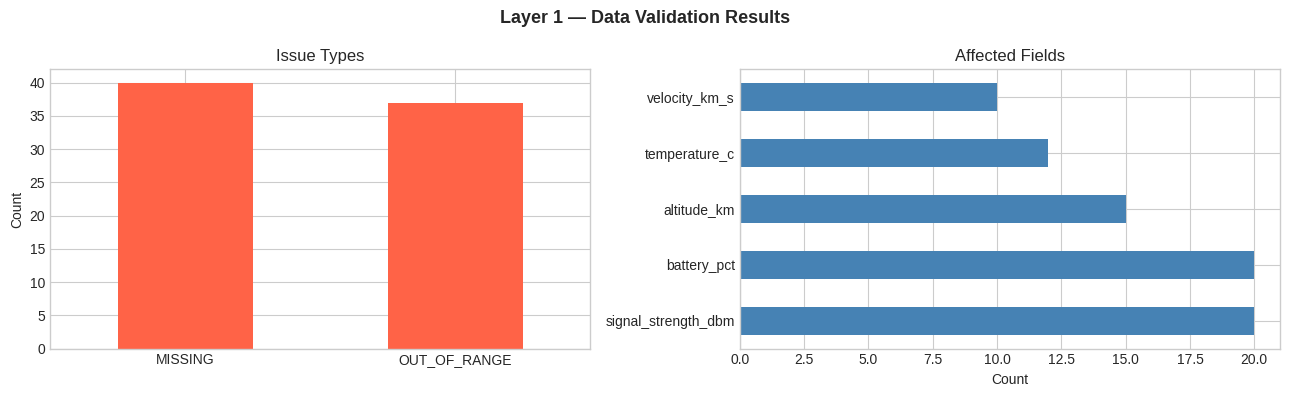


Sample invalid records:


,timestamp,satellite_id,altitude_km,velocity_km_s,validation_issues
7,2023-01-01 14:00:00,SAT-002,515.348695,7.626855,[MISSING:signal_strength_dbm]
34,2023-01-03 20:00:00,SAT-004,2500.000000,7.619816,[OUT_OF_RANGE:altitude_km=2500.00 (expected 20...
36,2023-01-04 00:00:00,SAT-001,504.177272,7.743885,"[MISSING:signal_strength_dbm, OUT_OF_RANGE:tem..."
37,2023-01-04 02:00:00,SAT-005,460.806598,15.000000,[OUT_OF_RANGE:velocity_km_s=15.00 (expected 6....
52,2023-01-05 08:00:00,SAT-002,486.461560,7.560313,[OUT_OF_RANGE:temperature_c=118.90 (expected -...
77,2023-01-07 10:00:00,SAT-002,494.019853,7.679666,[OUT_OF_RANGE:temperature_c=114.99 (expected -...


In [4]:
# Break down issues by type
all_issues = [issue for issues in df['validation_issues'] for issue in issues]
issue_types = pd.Series(all_issues).str.split(':').str[0].value_counts()
issue_fields = pd.Series(all_issues).str.split(':').str[1].str.split('=').str[0].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Layer 1 — Data Validation Results', fontsize=13, fontweight='bold')

issue_types.plot(kind='bar', ax=axes[0], color='tomato')
axes[0].set_title('Issue Types')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=0)

issue_fields.head(8).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Affected Fields')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('validation_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSample invalid records:')
df[~df.is_valid][['timestamp','satellite_id','altitude_km','velocity_km_s','validation_issues']].head(6)

In [5]:
# Separate clean and flagged data
df_clean   = df[df.is_valid].copy()
df_flagged = df[~df.is_valid].copy()

print(f'Clean records passed to anomaly detection: {len(df_clean):,}')
print(f'Flagged records quarantined for review:    {len(df_flagged):,}')

# Log flagged records (in production this writes to the audit ledger)
df_flagged[['timestamp','satellite_id','validation_issues']].to_csv('flagged_records_log.csv', index=False)
print('Flagged records logged to flagged_records_log.csv')

Clean records passed to anomaly detection: 1,125
Flagged records quarantined for review:    75
Flagged records logged to flagged_records_log.csv


## 4. Layer 2 — Anomaly Detection

Validation catches known bad data. Anomaly detection catches *unknown* bad data —
records that pass all range checks but represent unusual behavior in context.

We use two complementary approaches:
- **Z-score:** Fast univariate detection for individual sensor spikes
- **Isolation Forest:** Multivariate ML detection for complex orbital anomalies

In [6]:
# --- Method 1: Z-Score Detection ---
# Flag records where any key metric is more than 3 standard deviations from the mean

ZSCORE_FEATURES = ['altitude_km', 'velocity_km_s', 'temperature_c', 'signal_strength_dbm']
Z_THRESHOLD = 3.0

for feat in ZSCORE_FEATURES:
    z_col = f'zscore_{feat}'
    df_clean[z_col] = np.abs(stats.zscore(df_clean[feat].fillna(df_clean[feat].mean())))

zscore_cols = [f'zscore_{f}' for f in ZSCORE_FEATURES]
df_clean['max_zscore'] = df_clean[zscore_cols].max(axis=1)
df_clean['zscore_anomaly'] = df_clean['max_zscore'] > Z_THRESHOLD

print(f'Z-score anomalies detected: {df_clean.zscore_anomaly.sum()} '
      f'({df_clean.zscore_anomaly.mean():.1%} of clean records)')

Z-score anomalies detected: 25 (2.2% of clean records)


In [7]:
# --- Method 2: Isolation Forest (Multivariate) ---
# Detects anomalies based on combinations of features — catches subtle orbital irregularities
# that no single feature would flag alone

ISO_FEATURES = ['altitude_km', 'velocity_km_s', 'inclination_deg',
                'temperature_c', 'signal_strength_dbm', 'battery_pct']

# Fill remaining nulls with column medians for model input
X = df_clean[ISO_FEATURES].fillna(df_clean[ISO_FEATURES].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=100,
    contamination=0.04,   # expect ~4% anomaly rate
    random_state=42
)
df_clean['iso_prediction'] = iso.fit_predict(X_scaled)  # -1 = anomaly, 1 = normal
df_clean['iso_score']      = iso.score_samples(X_scaled) # lower = more anomalous
df_clean['iso_anomaly']    = df_clean['iso_prediction'] == -1

print(f'Isolation Forest anomalies detected: {df_clean.iso_anomaly.sum()} '
      f'({df_clean.iso_anomaly.mean():.1%} of clean records)')

Isolation Forest anomalies detected: 45 (4.0% of clean records)


In [8]:
# Combine both methods: flag if either detector raises an alert
df_clean['is_anomaly'] = df_clean['zscore_anomaly'] | df_clean['iso_anomaly']
df_clean['anomaly_source'] = 'none'
df_clean.loc[df_clean['zscore_anomaly'] & ~df_clean['iso_anomaly'], 'anomaly_source'] = 'zscore_only'
df_clean.loc[~df_clean['zscore_anomaly'] & df_clean['iso_anomaly'], 'anomaly_source'] = 'isolation_forest_only'
df_clean.loc[df_clean['zscore_anomaly'] & df_clean['iso_anomaly'],  'anomaly_source'] = 'both_methods'

print('=== Combined Anomaly Detection Summary ===')
print(df_clean['anomaly_source'].value_counts().to_string())
print(f'\nTotal anomalies flagged: {df_clean.is_anomaly.sum()} '
      f'({df_clean.is_anomaly.mean():.1%} of clean records)')

=== Combined Anomaly Detection Summary ===
anomaly_source
none                     1068
isolation_forest_only      32
both_methods               13
zscore_only                12

Total anomalies flagged: 57 (5.1% of clean records)


## 5. Visualization

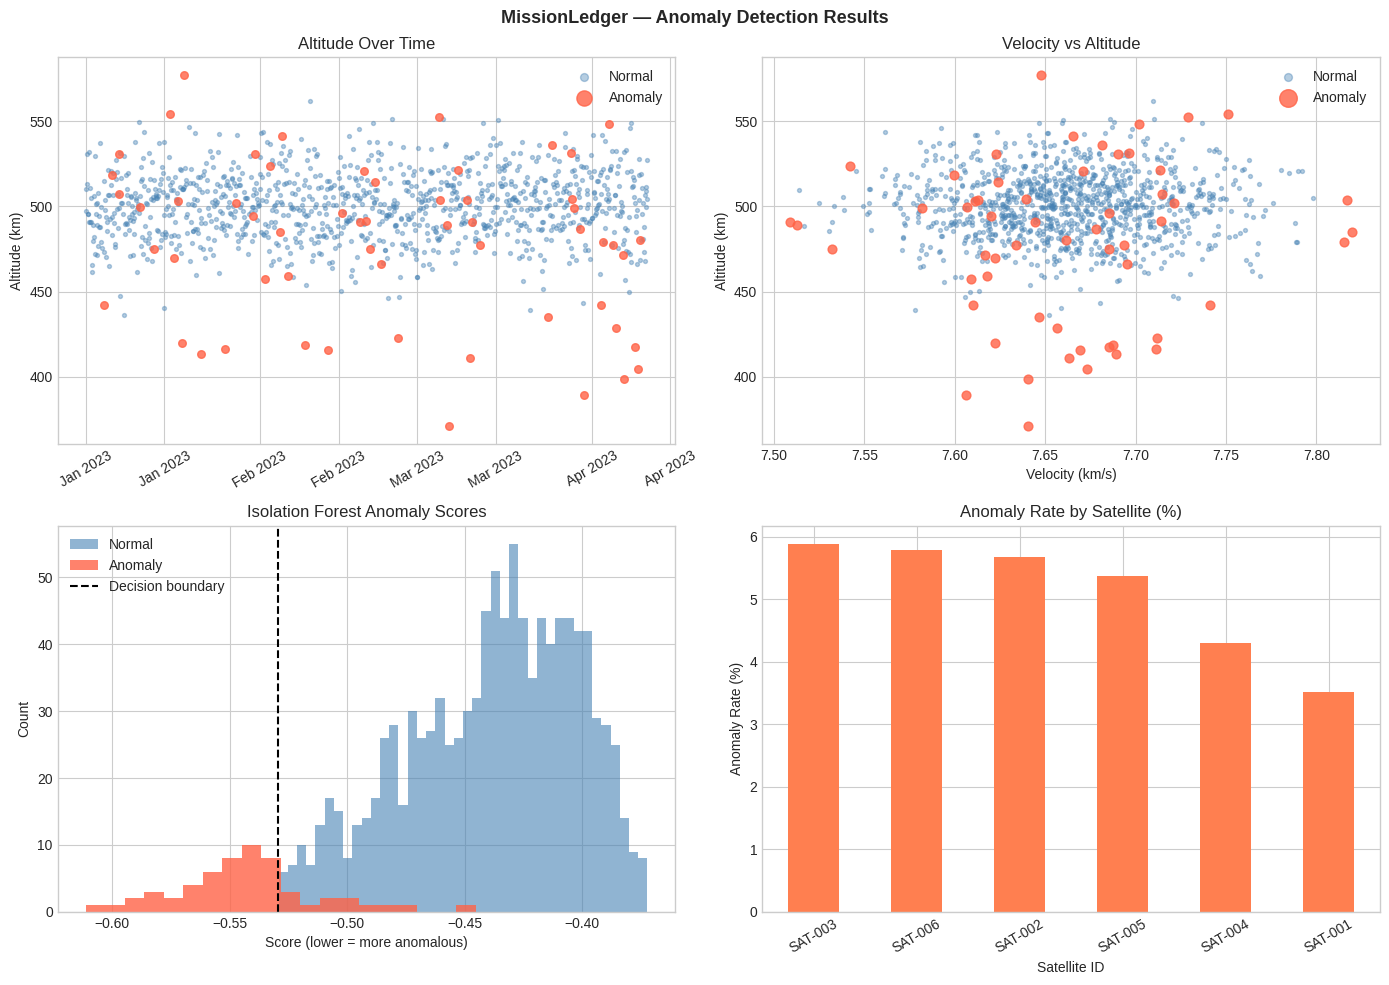

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MissionLedger — Anomaly Detection Results', fontsize=13, fontweight='bold')

normal   = df_clean[~df_clean['is_anomaly']]
anomalies = df_clean[df_clean['is_anomaly']]

# 1. Altitude over time with anomalies highlighted
axes[0, 0].scatter(normal['timestamp'],   normal['altitude_km'],
                   s=8, alpha=0.4, color='steelblue', label='Normal')
axes[0, 0].scatter(anomalies['timestamp'], anomalies['altitude_km'],
                   s=30, alpha=0.8, color='tomato', label='Anomaly', zorder=5)
axes[0, 0].set_title('Altitude Over Time')
axes[0, 0].set_ylabel('Altitude (km)')
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=30)
axes[0, 0].legend(markerscale=2)

# 2. Velocity vs Altitude scatter
axes[0, 1].scatter(normal['velocity_km_s'],   normal['altitude_km'],
                   s=8, alpha=0.4, color='steelblue', label='Normal')
axes[0, 1].scatter(anomalies['velocity_km_s'], anomalies['altitude_km'],
                   s=40, alpha=0.8, color='tomato', label='Anomaly', zorder=5)
axes[0, 1].set_title('Velocity vs Altitude')
axes[0, 1].set_xlabel('Velocity (km/s)')
axes[0, 1].set_ylabel('Altitude (km)')
axes[0, 1].legend(markerscale=2)

# 3. Isolation Forest anomaly scores
axes[1, 0].hist(normal['iso_score'],    bins=40, alpha=0.6, color='steelblue', label='Normal')
axes[1, 0].hist(anomalies['iso_score'], bins=20, alpha=0.8, color='tomato',    label='Anomaly')
axes[1, 0].axvline(iso.offset_, color='black', linestyle='--', linewidth=1.5, label='Decision boundary')
axes[1, 0].set_title('Isolation Forest Anomaly Scores')
axes[1, 0].set_xlabel('Score (lower = more anomalous)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

# 4. Anomaly rate by satellite
sat_anomaly_rate = df_clean.groupby('satellite_id')['is_anomaly'].mean() * 100
sat_anomaly_rate.sort_values(ascending=False).plot(kind='bar', ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Anomaly Rate by Satellite (%)')
axes[1, 1].set_ylabel('Anomaly Rate (%)')
axes[1, 1].set_xlabel('Satellite ID')
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('anomaly_detection_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Anomaly Report & Audit Log

All flagged records are written to the audit log for traceability. In the full MissionLedger system, this feeds into the blockchain-backed ledger so records cannot be altered after the fact.

In [10]:
print('=== Anomaly Report ===')
print(f'Records analyzed:      {len(df_clean):,}')
print(f'Anomalies detected:    {df_clean.is_anomaly.sum():,}')
print(f'Detection rate:        {df_clean.is_anomaly.mean():.1%}')

print('\nAnomaly breakdown by satellite:')
sat_report = df_clean.groupby('satellite_id').agg(
    total_records=('is_anomaly','count'),
    anomalies=('is_anomaly','sum'),
    anomaly_rate=('is_anomaly','mean')
).sort_values('anomaly_rate', ascending=False)
sat_report['anomaly_rate'] = sat_report['anomaly_rate'].map('{:.1%}'.format)
print(sat_report.to_string())

print('\nTop anomalous records:')
top_anomalies = df_clean[df_clean['is_anomaly']].sort_values('iso_score').head(8)
top_anomalies[['timestamp','satellite_id','altitude_km','velocity_km_s',
               'temperature_c','anomaly_source','iso_score']].to_string(index=False)

=== Anomaly Report ===
Records analyzed:      1,125
Anomalies detected:    57
Detection rate:        5.1%

Anomaly breakdown by satellite:
              total_records  anomalies anomaly_rate
satellite_id                                       
SAT-003                 170         10         5.9%
SAT-006                 190         11         5.8%
SAT-002                 194         11         5.7%
SAT-005                 186         10         5.4%
SAT-004                 186          8         4.3%
SAT-001                 199          7         3.5%

Top anomalous records:


'          timestamp satellite_id  altitude_km  velocity_km_s  temperature_c        anomaly_source  iso_score\n2023-04-09 06:00:00      SAT-002   404.868336       7.673014      23.890480          both_methods  -0.611301\n2023-03-04 22:00:00      SAT-004   552.647641       7.728722       8.392577 isolation_forest_only  -0.599869\n2023-03-06 14:00:00      SAT-006   371.137250       7.640574       4.341291          both_methods  -0.590895\n2023-04-04 00:00:00      SAT-004   548.068312       7.701947      26.382806 isolation_forest_only  -0.588972\n2023-03-30 14:00:00      SAT-001   389.515239       7.606447       5.648631          both_methods  -0.585208\n2023-02-19 20:00:00      SAT-006   491.114135       7.713800       4.857903 isolation_forest_only  -0.584023\n2023-04-04 18:00:00      SAT-006   477.073092       7.693437      13.114167          both_methods  -0.582365\n2023-03-29 22:00:00      SAT-005   486.567533       7.678182       5.614282 isolation_forest_only  -0.574850'

In [11]:
# Export audit log
audit_log = df_clean[df_clean['is_anomaly']][[
    'timestamp', 'satellite_id', 'altitude_km', 'velocity_km_s',
    'temperature_c', 'signal_strength_dbm', 'battery_pct',
    'anomaly_source', 'iso_score', 'max_zscore'
]].copy()
audit_log['flagged_at'] = pd.Timestamp.now()
audit_log.to_csv('anomaly_audit_log.csv', index=False)
print(f'Audit log written: {len(audit_log)} records → anomaly_audit_log.csv')

Audit log written: 57 records → anomaly_audit_log.csv


## 7. Summary

### What This Pipeline Does

| Layer | Method | What It Catches |
|---|---|---|
| Validation | Rule-based range checks | Missing fields, impossible sensor values |
| Anomaly Detection | Z-score (univariate) | Sudden spikes in individual metrics |
| Anomaly Detection | Isolation Forest (multivariate) | Subtle orbital irregularities across multiple signals |

### Key Results
- Validation layer catches structural data quality issues before they enter the ledger
- Z-score detection is fast and interpretable — good for real-time alerting
- Isolation Forest catches complex anomalies that no single metric would flag
- All flagged records are logged with full context for audit and review

### Potential Improvements
- **LSTM Autoencoder:** Learn expected temporal patterns per satellite for higher accuracy
- **Streaming pipeline:** Apply validation in real-time using Kafka or AWS Kinesis
- **Adaptive thresholds:** Update Z-score baselines dynamically as orbital parameters drift
- **Severity scoring:** Rank anomalies by operational risk to prioritize human review